In [1]:
!pip install -q nltk gensim

import re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection   import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics           import accuracy_score, classification_report, confusion_matrix, f1_score, make_scorer
from sklearn.pipeline          import Pipeline
from sklearn.linear_model     import LogisticRegression, SGDClassifier
from sklearn.naive_bayes      import MultinomialNB, BernoulliNB, ComplementNB
from sklearn.svm              import LinearSVC
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.linear_model     import PassiveAggressiveClassifier

In [2]:
df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
print('Shape:', df.shape)
print(df['sentiment'].value_counts())
df.head(5)

Shape: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
STOP_WORDS  = set(stopwords.words('english'))
print(STOP_WORDS)

{'just', 'against', 'than', 'off', "we'd", 'you', 'other', 'during', "wasn't", 's', 'then', 'd', 'the', 'himself', 'haven', 'do', 'how', 'm', 'be', 'itself', 'them', 'further', 'about', 'not', 'shan', "we're", 'mightn', 't', 'that', 'if', 'who', 'couldn', "they'd", 'does', 'he', "aren't", 'is', 'isn', 'theirs', 'but', 've', "don't", "that'll", 'until', 'once', "it'd", 'what', 'yourselves', 'few', 'up', 'doesn', "hadn't", 'wouldn', "doesn't", 'more', "he'd", 're', 'no', 'in', 'ma', 'own', "we'll", 'a', 'have', "he'll", 'same', 'was', 'of', 'this', 'didn', 'on', 'these', "i'd", "she'll", 'wasn', 'can', "needn't", 'from', "she'd", 'an', 'aren', 'our', 'which', 'him', 'y', 'did', 'or', 'as', 'all', "haven't", "mightn't", 'such', 'under', "she's", 'having', 'i', "weren't", 'won', 'any', "you've", "hasn't", 'again', "isn't", 'being', 'through', "i'm", 'o', 'those', 'will', 'are', 'mustn', 'her', 'ain', "i've", "wouldn't", 'and', 'll', 'above', 'weren', 'because', 'each', 'hadn', 'doing', 'ov

In [4]:
def preprocess(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    #KEEP_WORDS = {
    #    'not', 'no', 'nor', 'neither', 'never', 'nobody', 
    #    'nothing', 'nowhere', 'don', 'doesn', 'didn', 
    #    'won', 'wouldn', 'shouldn', 'couldn', 'isn', 'aren',
    #    'but', 'however', 'although', 'though',
    #    'very', 'too', 'so', 'most', 'more'
    #}
    #STOP_WORDS -= KEEP_WORDS
    lemmatizer  = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS]
    return ' '.join(tokens)

df['clean'] = df['review'].apply(preprocess)
df['label'] = (df['sentiment'] == 'positive').astype(int)

print('Original:', df['review'].iloc[0][:3141])
print('Cleaned :', df['clean'].iloc[0][:3141])

Original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due 

In [5]:
X = df['clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 40,000  |  Test: 10,000


In [6]:
bow = CountVectorizer(max_features=30000, ngram_range=(1,2))
X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)

tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

X_train_bern = (X_train_bow > 0).astype(int)
X_test_bern = (X_test_bow > 0).astype(int)

print(f'BoW   matrix: {X_train_bow.shape}')
print(f'TF-IDF matrix: {X_train_tfidf.shape}')
print(f'Bern matrix: {X_train_bern.shape}')

BoW   matrix: (40000, 30000)
TF-IDF matrix: (40000, 30000)
Bern matrix: (40000, 30000)


In [7]:
FEATURE_MAP = {
    'tfidf': (X_train_tfidf, X_test_tfidf),
    'bow':   (X_train_bow,   X_test_bow),
    'bern':  (X_train_bern,  X_test_bern)
}

CLASSIFIERS = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, C=1.0),
        'feat': 'tfidf'
    },
    'LinearSVC': {
        'model': LinearSVC(max_iter=2000),
        'feat': 'tfidf'
    },
    'SGD Classifier': {
        'model': SGDClassifier(loss='hinge', max_iter=100),
        'feat': 'tfidf'
    },
    'Passive Aggressive': {
        'model': PassiveAggressiveClassifier(max_iter=100),
        'feat': 'tfidf'
    },
    'Multinomial Naive Bayes': {
        'model': MultinomialNB(alpha=0.1, fit_prior=True),
        'feat': 'bow'
    },
    'Bernoulli Naive Bayes': {
        'model': BernoulliNB(alpha=0.01, binarize=None, fit_prior=True),
        'feat': 'bern'
    },
    'Complement Naive Bayes': {
        'model': ComplementNB(alpha=0.05, fit_prior=True),
        'feat': 'tfidf'
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(max_depth=20),
        'feat': 'tfidf'
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=100, n_jobs=-1),
        'feat': 'tfidf'
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(n_estimators=100),
        'feat': 'tfidf'
    },
    'K-Nearest Neighbors': {
        'model': KNeighborsClassifier(n_neighbors=5),
        'feat': 'tfidf'
    },
}

results = []

for name, cfg in CLASSIFIERS.items():
    Xtr, Xte = FEATURE_MAP[cfg['feat']]
    model = cfg['model']

    t0 = time.time()
    model.fit(Xtr, y_train)
    elapsed = time.time() - t0

    preds = model.predict(Xte)
    acc = accuracy_score(y_test, preds)
    rep = classification_report(y_test, preds, output_dict=True)

    results.append({
        'Model':     name,
        'Features':  cfg['feat'].upper(),
        'Accuracy':  round(acc*100, 2),
        'Precision': round(rep['weighted avg']['precision']*100, 2),
        'Recall':    round(rep['weighted avg']['recall']*100, 2),
        'F1-Score':  round(rep['weighted avg']['f1-score']*100, 2),
        'Time(s)':   round(elapsed, 2),
        '_preds':    preds,
        '_model':    model,
    })

In [8]:
results = sorted(results, key=lambda x: x['F1-Score'], reverse=True)

display_cols = ['Model', 'Features', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Time(s)']
df_results = pd.DataFrame(results)[display_cols]

df_results = df_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "=" * 81)
print("模型对比(按 F1 降序)")
print("=" * 81)
print(df_results.to_string(index=False))
print("=" * 81)


模型对比(按 F1 降序)
                  Model Features  Accuracy  Precision  Recall  F1-Score  Time(s)
              LinearSVC    TFIDF     89.95      89.96   89.95     89.95     1.83
         SGD Classifier    TFIDF     89.95      89.98   89.95     89.95     0.38
    Logistic Regression    TFIDF     89.90      89.91   89.90     89.90     1.47
     Passive Aggressive    TFIDF     88.45      88.45   88.45     88.45     0.65
 Complement Naive Bayes    TFIDF     87.85      87.87   87.85     87.85     0.04
  Bernoulli Naive Bayes     BERN     87.45      87.49   87.45     87.45     0.02
Multinomial Naive Bayes      BOW     87.07      87.07   87.07     87.07     0.03
          Random Forest    TFIDF     86.01      86.01   86.01     86.01    55.85
      Gradient Boosting    TFIDF     81.42      81.79   81.42     81.37   277.26
    K-Nearest Neighbors    TFIDF     76.29      76.94   76.29     76.15     0.02
          Decision Tree    TFIDF     74.57      75.31   74.57     74.38    35.20


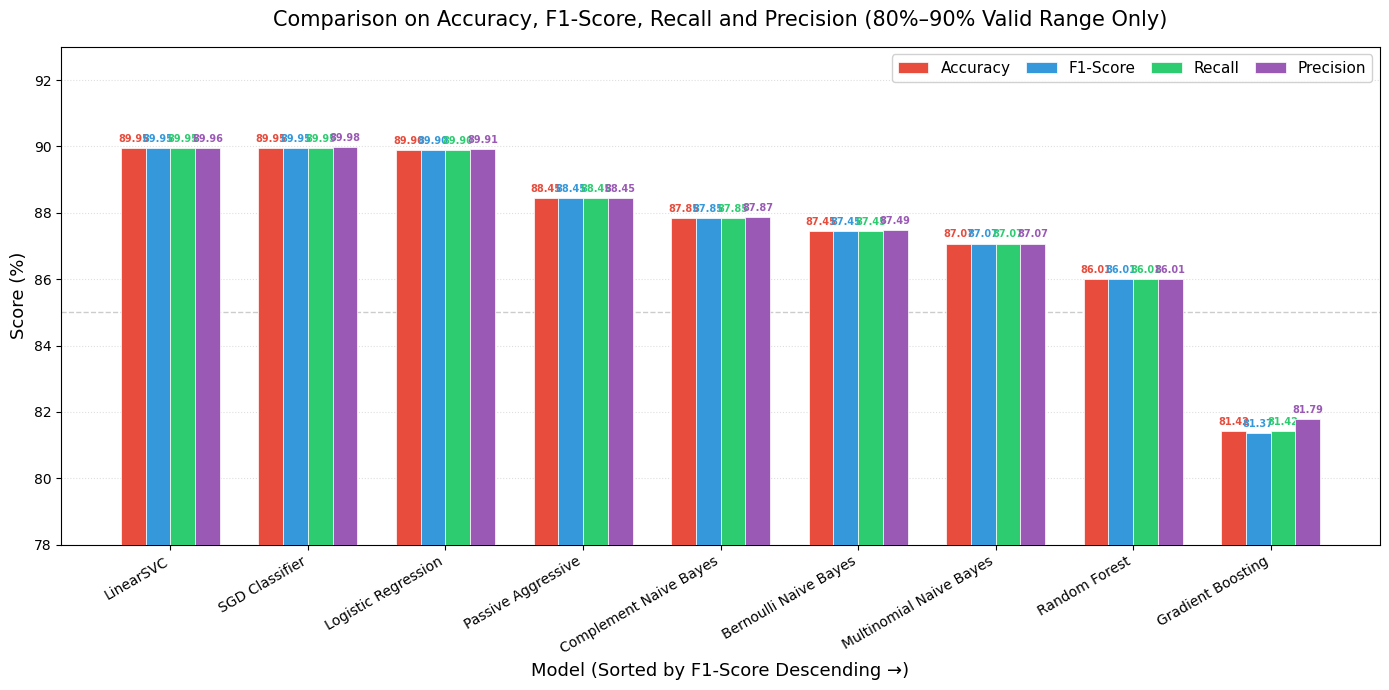

In [9]:
valid_results = [
    r for r in results
    if all(80 <= r[m] <= 90 for m in ['Accuracy', 'F1-Score', 'Recall', 'Precision'])
]

model_names = [r['Model'] for r in valid_results]
metrics_config = {
    'Accuracy':  {'color': '#E74C3C', 'data': [r['Accuracy']  for r in valid_results]},
    'F1-Score':  {'color': '#3498DB', 'data': [r['F1-Score']  for r in valid_results]},
    'Recall':    {'color': '#2ECC71', 'data': [r['Recall']    for r in valid_results]},
    'Precision': {'color': '#9B59B6', 'data': [r['Precision'] for r in valid_results]},
}

metric_labels = list(metrics_config.keys())
n_metrics = len(metric_labels)
n_models = len(model_names)

x = np.arange(n_models)
bar_width = 0.18
offsets = [(i - n_metrics / 2 + 0.5) * bar_width for i in range(n_metrics)]

fig, ax = plt.subplots(figsize=(14, 7))

bars_list = []
for i, (label, cfg) in enumerate(metrics_config.items()):
    bars = ax.bar(
        x + offsets[i],
        cfg['data'],
        width=bar_width,
        label=label,
        color=cfg['color'],
        edgecolor='white',
        linewidth=0.5,
        zorder=3
    )
    bars_list.append(bars)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height:.2f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center', va='bottom',
            fontsize=7, fontweight='bold', color=cfg['color']
        )

ax.legend(
    loc='upper right',
    fontsize=11,
    framealpha=0.9,
    ncol=4,
    columnspacing=1.0
)

ax.set_ylim(78, 93)
ax.set_ylabel('Score (%)', fontsize=13)
ax.set_xlabel('Model (Sorted by F1-Score Descending →)', fontsize=13)
ax.set_title('Comparison on Accuracy, F1-Score, Recall and Precision (80%–90% Valid Range Only)', fontsize=15, pad=15)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right')

ax.axhline(y=85, color='gray', linestyle='--', alpha=0.4, linewidth=1, zorder=1)

ax.grid(True, axis='y', linestyle=':', alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()